<a href="https://colab.research.google.com/github/vircanraluca/ApplicationVolunteer/blob/main/sephora_product_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import librarii
import pandas as pd                       #unealta principala pt tabele si date
import numpy as np                        #calcule matematice
import matplotlib.pyplot as plt           #unealta pentru grafice
import seaborn as sns                     #unealta pentru grafice mai frumpoasa

from sklearn.model_selection import train_test_split  #imparte datele in train/test
from sklearn.ensemble import RandomForestRegressor    #modelul nostru de ML
from sklearn.metrics import mean_absolute_error       #cat de bun e modelul


Dimensiunea datasetului: (8494, 27)


,product_id,product_name,brand_id,brand_name,loves_count,rating,reviews,size,variation_type,variation_value,...,online_only,out_of_stock,sephora_exclusive,highlights,primary_category,secondary_category,tertiary_category,child_count,child_max_price,child_min_price
0,P473671,Fragrance Discovery Set,6342,19-69,6320,3.6364,11.0,NaN,NaN,NaN,...,1,0,0,"['Unisex/ Genderless Scent', 'Warm &Spicy Scen...",Fragrance,Value & Gift Sets,Perfume Gift Sets,0,NaN,NaN
1,P473668,La Habana Eau de Parfum,6342,19-69,3827,4.1538,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,85.0,30.0
2,P473662,Rainbow Bar Eau de Parfum,6342,19-69,3253,4.2500,16.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
3,P473660,Kasbah Eau de Parfum,6342,19-69,3018,4.4762,21.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
4,P473658,Purple Haze Eau de Parfum,6342,19-69,2691,3.2308,13.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Perfume,2,75.0,30.0
5,P473661,Kasbah Eau de Parfum Travel Spray,6342,19-69,2448,4.4762,21.0,0.25 oz/ 7.5 mL,Size + Concentration + Formulation,0.25 oz/ 7.5 mL Eau de Parfum Spray,...,1,0,0,"['Warm &Spicy Scent', 'Unisex/ Genderless Scen...",Fragrance,Women,Rollerballs & Travel Size,0,NaN,NaN
6,P473659,Purple Haze Eau de Parfum Travel Spray,6342,19-69,1619,3.2308,13.0,0.25 oz/ 7.5 mL,Size + Concentration + Formulation,0.25 oz/ 7.5 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'Layerable Scent'...",Fragrance,Women,Rollerballs & Travel Size,0,NaN,NaN
7,P473666,Invisible Post Eau de Parfum,6342,19-69,1542,3.6250,8.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'allure 2022 Best...",Fragrance,Women,Perfume,2,75.0,30.0
8,P472300,Capri Eau de Parfum,6342,19-69,1542,3.5714,7.0,3.4 oz/ 100 mL,Size + Concentration + Formulation,3.4 oz/ 100 mL Eau de Parfum Spray,...,1,0,0,"['Fresh Scent', 'Layerable Scent', 'Unisex/ Ge...",Fragrance,Women,Perfume,2,75.0,30.0
9,P473667,Invisible Post Eau de Parfum Travel Spray,6342,19-69,1377,3.6250,8.0,0.25 oz/ 7.5 mL,Size + Concentration + Formulation,0.25 oz/ 7.5 mL,...,1,0,0,"['Unisex/ Genderless Scent', 'allure 2022 Best...",Fragrance,Women,Rollerballs & Travel Size,0,NaN,NaN


In [4]:
# ══════════════════════════════════════════
# ETAPA 3: Explorarea datelor (EDA)
# ══════════════════════════════════════════

# .columns îți arată numele tuturor celor 27 de coloane
print("Coloanele din dataset:")
print(df.columns.tolist())

Coloanele din dataset:
['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count', 'rating', 'reviews', 'size', 'variation_type', 'variation_value', 'variation_desc', 'ingredients', 'price_usd', 'value_price_usd', 'sale_price_usd', 'limited_edition', 'new', 'online_only', 'out_of_stock', 'sephora_exclusive', 'highlights', 'primary_category', 'secondary_category', 'tertiary_category', 'child_count', 'child_max_price', 'child_min_price']


In [5]:
# Selectăm doar coloanele cu care lucrăm
# Creăm un tabel nou, mai mic, doar cu ce ne trebuie
coloane_utile = [
    'brand_name',        # brandul produsului
    'rating',            # nota medie (1-5 stele)
    'reviews',           # numarul de recenzii
    'loves_count',       # de cate ori a fost "salvat" de useri
    'primary_category',  # categoria principala (ex: Skincare, Makeup)
    'limited_edition',   # 0 sau 1 — e editie limitata?
    'online_only',       # 0 sau 1 — se vinde doar online?
    'sephora_exclusive', # 0 sau 1 — exclusiv Sephora?
    'price_usd'          # TINTA — asta vrem sa prezice modelul
]

df_curat=df[coloane_utile].copy()

#verificam cum arata
print("Forma noului tabel: ",df_curat.shape)
print("\nPrimele 5 randuri:")
df_curat.head()


Forma noului tabel:  (8494, 9)

Primele 5 randuri:


,brand_name,rating,reviews,loves_count,primary_category,limited_edition,online_only,sephora_exclusive,price_usd
0,19-69,3.6364,11.0,6320,Fragrance,0,1,0,35.0
1,19-69,4.1538,13.0,3827,Fragrance,0,1,0,195.0
2,19-69,4.2500,16.0,3253,Fragrance,0,1,0,195.0
3,19-69,4.4762,21.0,3018,Fragrance,0,1,0,195.0
4,19-69,3.2308,13.0,2691,Fragrance,0,1,0,195.0


In [6]:
# .info() este ca un "raport medical" al tabelului tau
# iti arata pentru fiecare coloana:
# - cate valori NON-nule are (adica cate nu lipsesc)
# - ce tip de date e (numar, text, etc.)

df_curat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8494 entries, 0 to 8493
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand_name         8494 non-null   object 
 1   rating             8216 non-null   float64
 2   reviews            8216 non-null   float64
 3   loves_count        8494 non-null   int64  
 4   primary_category   8494 non-null   object 
 5   limited_edition    8494 non-null   int64  
 6   online_only        8494 non-null   int64  
 7   sephora_exclusive  8494 non-null   int64  
 8   price_usd          8494 non-null   float64
dtypes: float64(3), int64(4), object(2)
memory usage: 597.4+ KB


In [8]:
# .isnull().sum() numara cate valori LIPSESC din fiecare coloana
# o valoare lipsa = o celula goala in tabelul tau
# in ML, valorile lipsa sunt o problema — modelul nu stie
# ce sa faca cu o casuta goala

print("Valori lipsă per coloană:")
df_curat.isnull().sum()

Valori lipsă per coloană:


,0
brand_name,0
rating,278
reviews,278
loves_count,0
primary_category,0
limited_edition,0
online_only,0
sephora_exclusive,0
price_usd,0


In [9]:
# .describe() iti face un rezumat statistic al coloanelor numerice
# Min = cel mai mic pret
# Max = cel mai mare pret
# Mean = pretul mediu
# 50% = pretul "din mijloc" (median) — jumatate din produse costa mai putin

df_curat.describe()

,rating,reviews,loves_count,limited_edition,online_only,sephora_exclusive,price_usd
count,8216.000000,8216.000000,8.494000e+03,8494.000000,8494.000000,8494.000000,8494.000000
mean,4.194513,448.545521,2.917957e+04,0.070285,0.219096,0.279374,51.655595
std,0.516694,1101.982529,6.609212e+04,0.255642,0.413658,0.448718,53.669234
min,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000,3.000000
25%,3.981725,26.000000,3.758000e+03,0.000000,0.000000,0.000000,25.000000
50%,4.289350,122.000000,9.880000e+03,0.000000,0.000000,0.000000,35.000000
75%,4.530525,418.000000,2.684125e+04,0.000000,0.000000,1.000000,58.000000
max,5.000000,21281.000000,1.401068e+06,1.000000,1.000000,1.000000,1900.000000


Text(0, 0.5, 'Numar produse')

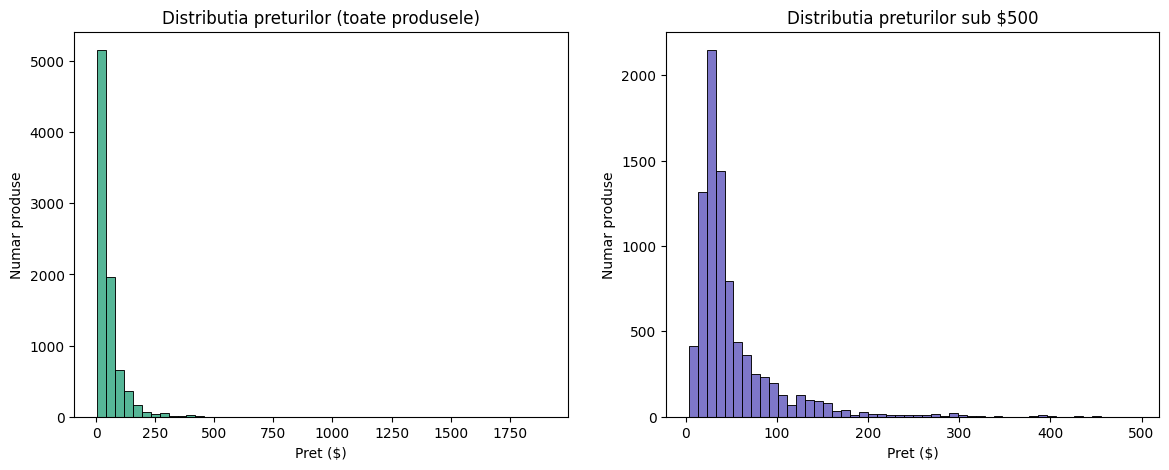

In [14]:
# Facem doua grafice side by side
# ca sa vedem distributia preturilor
fig, axes=plt.subplots(1,2,figsize=(14,5))

# Graficul 1: distributia bruta
# histplot = histogram — imparte preturile in "cosuri"
# si numara cate produse cad in fiecare cos

sns.histplot(df_curat['price_usd'],bins=50,ax=axes[0],color='#1D9E75')
axes[0].set_title('Distributia preturilor (toate produsele)')
axes[0].set_xlabel('Pret ($)')
axes[0].set_ylabel('Numar produse')

# Graficul 2: fara outlieri extremi
# ne uitam doar la produse sub $500
# ca sa vedem mai bine unde se concentreaza majoritatea
df_filtrat=df_curat[df_curat['price_usd']<500]
sns.histplot(df_filtrat['price_usd'], bins=50,ax=axes[1], color='#534AB7')
axes[1].set_title('Distributia preturilor sub $500')
axes[1].set_xlabel('Pret ($)')
axes[1].set_ylabel('Numar produse')

In [15]:
# ══════════════════════════════════════════
# ETAPA 4: Curățarea datelor
# ══════════════════════════════════════════

# PASUL 1: Valorile lipsă
# Știm că rating și reviews au 278 valori lipsă
# Soluția: le ștergem — 278 din 8494 e doar 3%, nu pierdem mult
# .dropna() = "drop not available" — șterge rândurile cu celule goale

df_curat=df_curat.dropna()
print("Randuri dupa stergerea valorilor lipsa: ",len(df_curat))
print("Randuri sterse",8894-len(df_curat))

Randuri dupa stergerea valorilor lipsa:  8216
Randuri sterse 678


In [18]:
# PASUL 2: Outlieri extremi la pret
# Produsele de $1900 sunt reale, dar sunt atat de rare
# incat ar incurca modelul — ar invata greu din 5 exemple de produse
# ultra-premium cand are 8000 de produse normale
# Pastram doar produsele sub $500 — acopera 99% din realitate

inainte = len(df_curat)
df_curat = df_curat[df_curat['price_usd']<500]
dupa=len(df_curat)

print("Produse eliminate ca outlieri:", inainte - dupa)
print("Produse ramase:", dupa)

Produse eliminate ca outlieri: 0
Produse ramase: 8215


In [19]:
# PASUL 3: Transformarea coloanelor de text in numere
# Modelul ML nu intelege cuvinte — nu stie ce inseamna "Skincare"
# Trebuie sa transformam textul in numere
#
# One-hot encoding = pentru fiecare valoare unica dintr-o coloana
# creezi o coloana noua cu 0 sau 1
#
# Exemplu pentru primary_category:
# Inainte:         Dupa:
# Skincare    →    cat_Skincare=1, cat_Makeup=0, cat_Hair=0
# Makeup      →    cat_Skincare=0, cat_Makeup=1, cat_Hair=0
# Hair        →    cat_Skincare=0, cat_Makeup=0, cat_Hair=1

print("Categorii unice in primary_category:")
print(df_curat['primary_category'].unique())
print("\nBranduri unice:", df_curat['brand_name'].nunique())

Categorii unice in primary_category:
['Fragrance' 'Bath & Body' 'Mini Size' 'Hair' 'Makeup' 'Skincare'
 'Tools & Brushes' 'Men' 'Gifts']

Branduri unice: 302


In [20]:
# Verificare rapida
print("Produse totale:", len(df_curat))
print("Pret maxim acum:", df_curat['price_usd'].max())
print("Pret minim acum:", df_curat['price_usd'].min())

Produse totale: 8215
Pret maxim acum: 465.0
Pret minim acum: 3.0


In [23]:
# PASUL 4: Tratarea brandurilor
# Avem 302 branduri — prea multe pentru one-hot encoding direct
# Solutia: pastram top 20 branduri, restul devin "Other"

# .value_counts() numara cate produse are fiecare brand
# .head(20) ia primele 20 (cele mai frecvente)
# .index extrage doar numele brandurilor, fara numere

top_branduri=df_curat['brand_name'].value_counts().head(20).index

print("Top 20 branduri dupa numar de produse ")
print(top_branduri.tolist())

Top 20 branduri dupa numar de produse 
['SEPHORA COLLECTION', 'CLINIQUE', 'Dior', 'tarte', 'Kérastase', 'Bumble and bumble', 'Charlotte Tilbury', 'TOM FORD', 'Anastasia Beverly Hills', 'NEST New York', 'Moroccanoil', 'Oribe', 'Hourglass', 'Fenty Beauty by Rihanna', 'Jo Malone London', 'Lancôme', 'Drybar', 'MAKE UP FOR EVER', 'Benefit Cosmetics', "Kiehl's Since 1851"]


In [27]:
# PASUL 5: Înlocuim brandurile rare cu "Other"
# .apply() aplică o funcție pe fiecare valoare din coloană
# lambda e o funcție micuță scrisă pe loc, fără nume
# citește așa: "pentru fiecare brand x,
#              dacă x e în top_branduri → păstrează-l
#              dacă nu → înlocuiește-l cu 'Other'"

df_curat['brand_name'] = df_curat['brand_name'].apply(
    lambda x: x if x in top_branduri else 'Other'
)

print("Branduri unice acum:",df_curat['brand_name'].nunique())
print(df_curat['brand_name'].value_counts())

Branduri unice acum: 21
brand_name
Other                      6055
SEPHORA COLLECTION          351
CLINIQUE                    177
Dior                        133
tarte                       126
Kérastase                   107
Bumble and bumble           107
Charlotte Tilbury            98
TOM FORD                     97
Anastasia Beverly Hills      94
NEST New York                92
Moroccanoil                  88
Oribe                        87
Hourglass                    85
Fenty Beauty by Rihanna      81
Jo Malone London             80
Lancôme                      76
Benefit Cosmetics            71
Drybar                       71
MAKE UP FOR EVER             71
Kiehl's Since 1851           68
Name: count, dtype: int64


In [32]:
# PASUL 6: One-hot encoding
# pd.get_dummies() face automat transformarea pentru toate
# coloanele de text din lista pe care i-o dam
#
# Inainte:  brand_name="Dior", primary_category="Makeup"
# Dupa:     brand_name_Dior=1, brand_name_Other=0, ...
#           primary_category_Makeup=1, primary_category_Skincare=0, ...
#
# drop_first=True elimina prima coloana din fiecare grup
# Ex: daca avem Skincare=0 si Makeup=0 si Hair=0
# stim deja ca produsul e din alta categorie — coloana e redundanta

df_encoded=pd.get_dummies(
    df_curat,
    columns=['brand_name', 'primary_category'],
    drop_first=False
)

print("Coloane inainte de encoding ", len(df_curat.columns))
print("Coloane dupa encoding ", len(df_encoded.columns))
print("\nPrimele coloane noi create:")
print([col for col in df_encoded.columns if 'brand' in col or 'category' in col][:10])

Coloane inainte de encoding  9
Coloane dupa encoding  37

Primele coloane noi create:
['brand_name_Anastasia Beverly Hills', 'brand_name_Benefit Cosmetics', 'brand_name_Bumble and bumble', 'brand_name_CLINIQUE', 'brand_name_Charlotte Tilbury', 'brand_name_Dior', 'brand_name_Drybar', 'brand_name_Fenty Beauty by Rihanna', 'brand_name_Hourglass', 'brand_name_Jo Malone London']


In [35]:
# PASUL 7: Separăm X și y
# Acesta e un concept fundamental in ML — trebuie sa separi
# "intrarile" (ce ii dai modelului) de "iesirea" (ce vrei sa prezica)
#
# X = toate coloanele EXCEPT pretul — sunt "intrarile"
#     adica: brand, rating, reviews, categorie...
# y = DOAR coloana price_usd — e "iesirea", tinta noastra
#
# Analogie: X = ingredientele unei retete, y = felul de mancare final

X = df_encoded.drop('price_usd',axis=1)
y = df_encoded['price_usd']

print("Forma X (intrari): ",X.shape)
print("Forma Y (iesiri):",y.shape)
print("\nPrimele 5 pereturi din y:")
print(y.head())

Forma X (intrari):  (8215, 36)
Forma Y (iesiri): (8215,)

Primele 5 pereturi din y:
0     35.0
1    195.0
2    195.0
3    195.0
4    195.0
Name: price_usd, dtype: float64


In [37]:
# PASUL 8: Impartim datele in train si test
# Acesta e unul din cele mai importante concepte in ML!
#
# Nu poti testa modelul pe aceleasi date pe care a invatat
# E ca si cum dai elevului exact testul pe care l-a studiat —
# nu afli daca a inteles, ci doar daca a memorat
#
# test_size=0.2 = 20% din date merg la testare, 80% la invatare
# random_state=42 = un numar fix ca sa obtii mereu acelasi rezultat
#                   cand "amesteci" datele inainte de impartire

X_train, X_test, y_train,y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Date de antrare: ",X_train.shape)
print("Date de testare: ", X_test.shape)
print(f"\nModelul va invata din {len(X_train)} produse")
print(f"si va fi testa pe {len(X_test)} produse nevazute")

Date de antrare:  (6572, 36)
Date de testare:  (1643, 36)

Modelul va invata din 6572 produse
si va fi testa pe 1643 produse nevazute


In [39]:
# ══════════════════════════════════════════
# ETAPA 5: Antrenarea modelului
# ══════════════════════════════════════════

# Cream modelul — inca nu a invatat nimic, e ca un elev nou
# n_estimators=100 = cate arbori vrem in padurea noastra
# random_state=42 = ca sa obtinem mereu acelasi rezultat

model = RandomForestRegressor(n_estimators=100, random_state=42)

# .fit() = "invata din aceste date"
# ii dam X_train (intrarile) si y_train (preturile corecte)
# modelul studiaza mii de produse si invata tipare:
# "cand brand=Dior si category=Makeup, pretul tinde sa fie ~$50"
print("Modelul invata... (poate dura 10-30 secunde)")
model.fit(X_train, y_train)

print("Antrenare finalizata ")


Modelul invata... (poate dura 10-30 secunde)
Antrenare finalizata 


In [41]:
from sklearn.metrics import mean_absolute_error, r2_score

In [42]:
# ══════════════════════════════════════════
# ETAPA 6: Evaluarea modelului
# ══════════════════════════════════════════

# .predict() = "ghiceste pretul pentru aceste produse"
# ii dam X_test — produsele nevazute
# modelul returneaza preturile prezise de el
y_pred = model.predict(X_test)

# mean_absolute_error = eroarea medie absoluta (MAE)
# adica: in medie, cu cati dolari greseste modelul?
# Ex: MAE=15 inseamna ca in medie greseste cu $15
mae = mean_absolute_error(y_test, y_pred)

# r2_score = cat la suta din variatia preturilor
# o explica modelul nostru
# 1.0 = perfect, 0.0 = la fel de bun ca sa ghicesti mereu media
# 0.8+ = foarte bun, 0.6+ = decent, sub 0.5 = slab
r2 = r2_score(y_test, y_pred)

print(f"Eroare medie (MAE): ${mae:.2f}")
print(f"Scor R²: {r2:.3f}")
print(f"\nAdica modelul greseste in medie cu ${mae:.2f} per produs")
print(f"Si explica {r2*100:.1f}% din variatia preturilor")

Eroare medie (MAE): $26.23
Scor R²: 0.193

Adica modelul greseste in medie cu $26.23 per produs
Si explica 19.3% din variatia preturilor


In [43]:
# Sa vedem ce coloane a considerat modelul importante
# feature_importances_ = cat a contat fiecare coloana
# pentru deciziile modelului (valori intre 0 si 1, suma = 1)

importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 15 cele mai importante caracteristici:")
print(importances.head(15))

Top 15 cele mai importante caracteristici:
loves_count                      0.274090
rating                           0.204612
reviews                          0.198933
primary_category_Fragrance       0.108427
brand_name_TOM FORD              0.048007
primary_category_Skincare        0.039710
online_only                      0.029825
sephora_exclusive                0.025546
limited_edition                  0.012274
brand_name_Other                 0.007865
brand_name_SEPHORA COLLECTION    0.007724
brand_name_Jo Malone London      0.005720
brand_name_NEST New York         0.004309
brand_name_Lancôme               0.004170
brand_name_Drybar                0.004078
dtype: float64


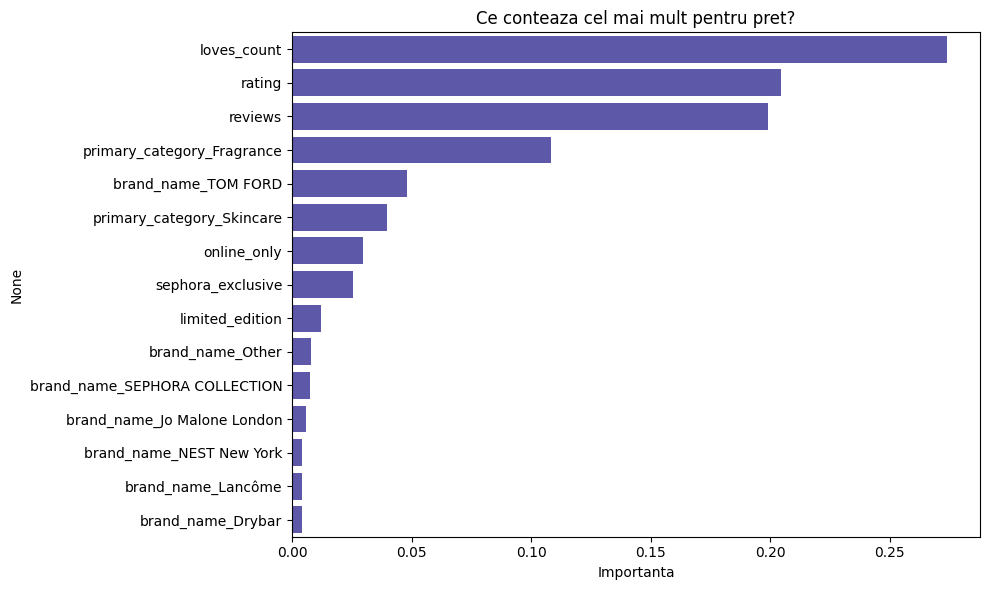

In [44]:
# Vizualizam grafic
plt.figure(figsize=(10, 6))
sns.barplot(x=importances.head(15).values,
            y=importances.head(15).index,
            color='#534AB7')
plt.title('Ce conteaza cel mai mult pentru pret?')
plt.xlabel('Importanta')
plt.tight_layout()
plt.show()

In [45]:
# Sa vedem distributia erorilor
# adica: unde greseste cel mai mult modelul?

df_rezultate = pd.DataFrame({
    'pret_real': y_test,
    'pret_prezis': y_pred,
    'eroare': abs(y_test - y_pred)
})

print("Produse unde modelul a gresit cel mai mult:")
print(df_rezultate.sort_values('eroare', ascending=False).head(10))

print("\nProduse unde modelul a ghicit cel mai bine:")
print(df_rezultate.sort_values('eroare').head(10))

Produse unde modelul a gresit cel mai mult:
      pret_real  pret_prezis    eroare
5545      449.0      45.2496  403.7504
4313      425.0      69.9700  355.0300
5554      399.0      61.9500  337.0500
2092      360.0      86.5900  273.4100
3295      320.0      48.4500  271.5500
604       299.0      34.6200  264.3800
428       305.0      42.9300  262.0700
4335      300.0      42.9400  257.0600
4326      320.0      71.2800  248.7200
2708      299.0      54.2200  244.7800

Produse unde modelul a ghicit cel mai bine:
      pret_real  pret_prezis  eroare
3182       48.0      48.0200  0.0200
891        30.0      29.9590  0.0410
6689       17.0      17.0448  0.0448
7932       56.0      56.0800  0.0800
8363       25.0      24.9100  0.0900
6437       13.0      12.9100  0.0900
7893       38.0      37.8995  0.1005
3332       27.0      26.8899  0.1101
7049       42.0      42.1800  0.1800
5185       48.0      47.8150  0.1850


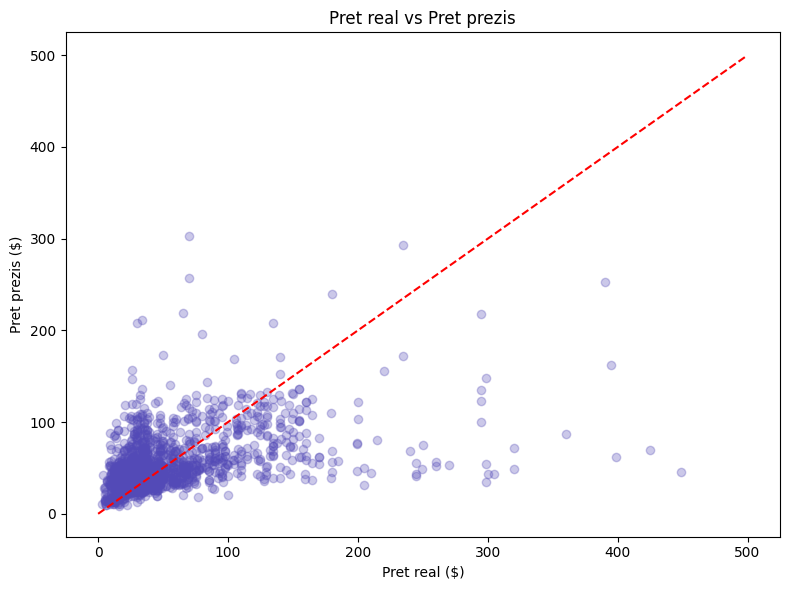

In [46]:
# Grafic: pret real vs pret prezis
# Daca modelul ar fi perfect, toate punctele ar fi pe linia diagonala
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='#534AB7')
plt.plot([0, 500], [0, 500], 'r--', linewidth=1.5)
plt.xlabel('Pret real ($)')
plt.ylabel('Pret prezis ($)')
plt.title('Pret real vs Pret prezis')
plt.tight_layout()
plt.show()